# Reporte de ejemplos — Estimación puntual

**Diplomado en Técnicas Estadísticas y Minería de Datos — Unidad 2**

**Autor:** yagoraulhuertaorozco@gmail.com

**Fecha:** 29 de septiembre de 2026

---

<a id="introduccion"></a>
## 1. Introducción

Este cuaderno recorre los tres ejemplos del archivo `07_Ejercicios_estimacion_puntual.pdf` sobre **estimación puntual**: el concepto de estadística, el método de momentos y el método de máxima verosimilitud. Se utiliza `sympy` para verificar las derivaciones simbólicas, `scipy.stats` para evaluar la densidad normal y `scipy.optimize` para obtener los estimadores por máxima verosimilitud de manera numérica.

Los ejemplos son:

- **Ejemplo 5.1 (Estadísticas)** — ejemplos de estadísticas a partir de una muestra aleatoria exponencial.
- **Ejemplo 5.2 (Método de momentos)** — estimación de $\mu$ y $\sigma^2$ en una muestra $N(\mu, \sigma^2)$.
- **Ejemplo 5.3 (Máxima verosimilitud)** — los mismos parámetros estimados por máxima verosimilitud, con la superficie de verosimilitud y la optimización numérica.

<a id="indice"></a>
## 2. Índice

- [1. Introducción](#introduccion)
- [2. Índice](#indice)
- [3. Configuración inicial](#setup)
- [4. Ejemplo 5.1 — Estadísticas](#ej51)
- [5. Ejemplo 5.2 — Método de momentos](#ej52)
- [6. Ejemplo 5.3 — Máxima verosimilitud](#ej53)
- [7. Conclusiones](#conclusiones)

<a id="setup"></a>
## 3. Configuración inicial

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sympy as sp
from scipy.optimize import minimize
from scipy.stats import expon, norm

sp.init_printing(use_latex="mathjax")

sns.set_theme(style="whitegrid", rc={
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "grid.color": "#e1e0d9",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "font.family": "sans-serif",
})

PALETTE_CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
COLOR_HIGHLIGHT = "#e34948"
COLOR_MEAN = "#e34948"

rng = np.random.default_rng(seed=20260929)

<a id="ej51"></a>
## 4. Ejemplo 5.1 — Estadísticas

Una **estadística** es cualquier función de la muestra aleatoria $X_1, X_2, \dots, X_n$ que **no depende de parámetros desconocidos**. En consecuencia, una estadística es una variable aleatoria cuya distribución puede (al menos en principio) determinarse.

Si $X_1, X_2, \dots, X_n$ es una muestra aleatoria exponencial con parámetro $\beta$ (escala, es decir $E[X_i] = \beta$), ejemplos clásicos de estadísticas son:

$$
t_1 = \frac{1}{n} \sum_{i=1}^{n} X_i, \qquad
t_2 = \text{med}\{X_1, \dots, X_n\}, \qquad
t_3 = \sum_{i=1}^{n} X_i.
$$

Verificamos estas tres cantidades sobre una muestra exponencial concreta.

In [2]:
# Muestra exponencial con parametro beta (escala) = 1.5 -> media = 1.5
beta_escala = 1.5
n_exp = 50
muestra_exp = rng.exponential(scale=beta_escala, size=n_exp)
muestra_exp[:8]

array([5.15898523e-01, 3.24274391e+00, 1.62928180e+00, 5.01657442e-02,
       1.77497852e-03, 1.86618175e+00, 4.99851555e-01, 5.13646001e-01])

In [3]:
t1_media = float(np.mean(muestra_exp))
t2_mediana = float(np.median(muestra_exp))
t3_suma = float(np.sum(muestra_exp))

print(f"n                = {n_exp}")
print(f"beta (verdadero) = {beta_escala}")
print(f"t1 = media       = {t1_media:.4f}")
print(f"t2 = mediana     = {t2_mediana:.4f}")
print(f"t3 = suma        = {t3_suma:.4f}")
print(f"E[X_i] = beta    = {beta_escala}")
print(f"|t1 - beta|      = {abs(t1_media - beta_escala):.4f}  (sesgo esperado de la media)")

n                = 50
beta (verdadero) = 1.5
t1 = media       = 1.5269
t2 = mediana     = 1.0893
t3 = suma        = 76.3457
E[X_i] = beta    = 1.5
|t1 - beta|      = 0.0269  (sesgo esperado de la media)


**Observaciones sobre el Ejemplo 5.1.**

- Las tres cantidades $t_1, t_2, t_3$ son **estadísticas** porque se calculan únicamente a partir de la muestra, sin recurrir a $\beta$ (el único parámetro desconocido).
- $t_1$ y $t_2$ son estimadores **naturales** del parámetro $\beta$ (la media poblacional), aunque $t_3$ también lo es indirectamente a través de $t_3 / n = t_1$.
- La media muestral $t_1$ es, además, **insesgada** para $\beta$: $E[t_1] = \beta$. La mediana $t_2$, en cambio, tiene un sesgo pequeño que se atenúa cuando $n$ crece.

[Volver al índice](#indice)

<a id="ej52"></a>
## 5. Ejemplo 5.2 — Método de momentos

Sea $X_1, X_2, \dots, X_n$ una muestra aleatoria con distribución $N(\mu, \sigma^2)$. Se quiere encontrar los estimadores puntuales de $\mu$ y $\sigma^2$ por el **método de momentos**.

Como hay dos parámetros desconocidos, se igualan los dos primeros momentos poblacionales con los dos primeros momentos muestrales:

$$
E[X] = \bar{X}, \qquad E[X^2] = \frac{1}{n} \sum_{i=1}^{n} X_i^2.
$$

Para una $N(\mu, \sigma^2)$ se sabe que $E[X] = \mu$ y $E[X^2] = \mu^2 + \sigma^2$.

In [4]:
x, mu_pop, sigma_pop = sp.symbols("x mu_pop sigma_pop", real=True)
sigma_pos = sp.Symbol("sigma_pos", positive=True)
mu_real = sp.Symbol("mu_real", real=True)

# Densidad normal N(mu, sigma^2)
f_norm = 1 / (sigma_pos * sp.sqrt(2 * sp.pi)) * sp.exp(-(x - mu_real) ** 2 / (2 * sigma_pos ** 2))
f_norm

                 2 
    -(-μᵣₑₐₗ + x)  
    ───────────────
              2    
        2⋅σₚₒₛ     
√2⋅ℯ               
───────────────────
     2⋅√π⋅σₚₒₛ     

In [5]:
# Primer momento poblacional
EX = sp.integrate(x * f_norm, (x, -sp.oo, sp.oo))
EX

μᵣₑₐₗ

In [6]:
# Segundo momento poblacional
EX2 = sp.integrate(x ** 2 * f_norm, (x, -sp.oo, sp.oo))
EX2

     2       2
μᵣₑₐₗ  + σₚₒₛ 

In [7]:
# Varianza poblacional = E[X^2] - E[X]^2
VarX = sp.simplify(EX2 - EX ** 2)
VarX

    2
σₚₒₛ 

Con esto ya podemos plantear el método de momentos:

$$
\mu \overset{\text{pob}}{=} E[X] = \bar{X} \;\Rightarrow\; \hat{\mu}_{\text{MoM}} = \bar{X},
$$

$$
\sigma^2 \overset{\text{pob}}{=} E[X^2] - E[X]^2 = \frac{1}{n} \sum_{i=1}^{n} X_i^2 - \bar{X}^2 = \frac{1}{n} \sum_{i=1}^{n} (X_i - \bar{X})^2 \;\Rightarrow\; \hat{\sigma}^2_{\text{MoM}} = \frac{1}{n} \sum_{i=1}^{n} (X_i - \bar{X})^2.
$$

Verificamos estos estimadores con una muestra simulada de $N(1, 1)$, igual que en el PDF.

In [8]:
n_norm = 100
muestra_norm = rng.normal(loc=1, scale=1, size=n_norm)
muestra_norm[:6]

array([ 0.70976195,  0.13012774,  0.08371383,  0.84173589, -0.24190568,
        0.93742514])

In [9]:
# Estimadores por metodo de momentos
mu_MoM = float(np.mean(muestra_norm))
sigma2_MoM = float(np.sum((muestra_norm - mu_MoM) ** 2) / n_norm)
sigma_MoM = math.sqrt(sigma2_MoM)

# Estimadores de maxima verosimilitud para comparar (mismos aqui, pero distinto denominador)
sigma2_MLE = float(np.sum((muestra_norm - mu_MoM) ** 2) / (n_norm - 1))
sigma_MLE = math.sqrt(sigma2_MLE)

print(f"n                 = {n_norm}")
print(f"mu verdadero      = 1.0")
print(f"sigma^2 verdadero = 1.0")
print()
print(f"mu_MoM            = {mu_MoM:.6f}")
print(f"sigma^2_MoM       = {sigma2_MoM:.6f}   <- divisor n (insesgado para sigma^2 si se corrige)")
print(f"sigma^2_MLE       = {sigma2_MLE:.6f}   <- divisor n-1")
print()
print(f"NOTA: Con el metodo de momentos el estimador natural de sigma^2 usa divisor n.")
print(f"      El estimador por maxima verosimilitud que veremos en 5.3 dara exactamente")
print(f"      el mismo resultado (divisor n) que mu_MoM^sigma2.")

n                 = 100
mu verdadero      = 1.0
sigma^2 verdadero = 1.0

mu_MoM            = 0.790448
sigma^2_MoM       = 0.883958   <- divisor n (insesgado para sigma^2 si se corrige)
sigma^2_MLE       = 0.892886   <- divisor n-1

NOTA: Con el metodo de momentos el estimador natural de sigma^2 usa divisor n.
      El estimador por maxima verosimilitud que veremos en 5.3 dara exactamente
      el mismo resultado (divisor n) que mu_MoM^sigma2.


**Conclusión 5.2.** El método de momentos produce:

$$
\hat{\mu}_{\text{MoM}} = \bar{X}, \qquad \hat{\sigma}^2_{\text{MoM}} = \frac{1}{n} \sum_{i=1}^{n} (X_i - \bar{X})^2.
$$

Con la muestra simulada ($n=100$, semilla `20260929`):

- $\hat{\mu}_{\text{MoM}} = \bar{X} \approx 0.790$
- $\hat{\sigma}^2_{\text{MoM}} \approx 0.884$

El estimador $\hat{\sigma}^2_{\text{MoM}}$ con divisor $n$ **no** es insesgado: su valor esperado es $\frac{n-1}{n}\sigma^2$. El estimador insesgado usa divisor $n-1$ (que es exactamente lo que produce `numpy.var(..., ddof=1)` o `scipy.stats.tvar`). En el siguiente ejemplo lo confirmaremos con la verosimilitud.

[Volver al índice](#indice)

<a id="ej53"></a>
## 6. Ejemplo 5.3 — Máxima verosimilitud

Sea $X_1, \dots, X_n$ una muestra aleatoria con distribución $N(\mu, \sigma^2)$. La densidad de una observación es

$$
f(x; \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left\{-\frac{(x-\mu)^2}{2\sigma^2}\right\}.
$$

La función de verosimilitud es el producto de las densidades evaluadas en cada $X_i$:

$$
L(\mu, \sigma^2) = \prod_{i=1}^{n} f(X_i; \mu, \sigma^2) = (2\pi\sigma^2)^{-n/2} \exp\!\left\{-\frac{1}{2\sigma^2} \sum_{i=1}^{n} (X_i - \mu)^2 \right\},
$$

y su logaritmo (que es más fácil de maximizar) es

$$
\ell(\mu, \sigma^2) = -\frac{n}{2} \ln(2\pi) - \frac{n}{2} \ln(\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^{n} (X_i - \mu)^2.
$$

Maximizamos derivando parcialmente e igualando a cero.

In [10]:
# Variables simbolicas
mu_s, sigma2_s = sp.symbols("mu sigma2", real=True)
sigma2_pos = sp.Symbol("sigma2", positive=True)
n_s = sp.Symbol("n", positive=True, integer=True)

# Estadisticos muestrales como simbolos
suma_x = sp.Symbol("S_x")           # sum X_i
suma_x2 = sp.Symbol("S_x2")         # sum X_i^2

# Log-verosimilitud (la integral bajo el sumatorio se colapsa a estos dos estadisticos)
log_lik = -n_s / 2 * sp.log(2 * sp.pi) - n_s / 2 * sp.log(sigma2_pos) - (suma_x2 - 2 * mu_s * suma_x + n_s * mu_s ** 2) / (2 * sigma2_pos)
log_lik

                                            2  
  n⋅log(σ₂)   n⋅log(2⋅π)   -2⋅Sₓ⋅μ + Sₓ₂ + μ ⋅n
- ───────── - ────────── - ────────────────────
      2           2                2⋅σ₂        

In [11]:
# Derivada parcial respecto a mu e igualada a cero
d_mu = sp.diff(log_lik, mu_s)
sol_mu = sp.solve(sp.Eq(d_mu, 0), mu_s)[0]
d_mu, sol_mu

⎛-(-2⋅Sₓ + 2⋅μ⋅n)   Sₓ⎞
⎜─────────────────, ──⎟
⎝      2⋅σ₂         n ⎠

In [12]:
# Derivada parcial respecto a sigma^2 e igualada a cero
d_sigma2 = sp.diff(log_lik, sigma2_pos)
sol_sigma2 = sp.solve(sp.Eq(d_sigma2, 0), sigma2_pos)[0]
d_sigma2, sol_sigma2

⎛                          2                     2  ⎞
⎜   n     -2⋅Sₓ⋅μ + Sₓ₂ + μ ⋅n  -2⋅Sₓ⋅μ + Sₓ₂ + μ ⋅n⎟
⎜- ──── + ────────────────────, ────────────────────⎟
⎜  2⋅σ₂              2                   n          ⎟
⎝                2⋅σ₂                               ⎠

In [13]:
# Sustituyendo S_x = n * X_bar en mu_hat
X_bar = sp.Symbol("X_bar")
mu_hat = sp.simplify(sol_mu.subs(suma_x, n_s * X_bar))
mu_hat

X_bar

In [14]:
# Y para sigma^2_hat, sustituimos la expresion completa
sigma2_hat = sp.simplify(sol_sigma2.subs(suma_x, n_s * X_bar))
sigma2_hat

Sₓ₂                2
─── - 2⋅X_bar⋅μ + μ 
 n                  

Las ecuaciones de verosimilitud producen los estimadores:

$$
\hat{\mu}_{\text{MLE}} = \bar{X}, \qquad \hat{\sigma}^2_{\text{MLE}} = \frac{1}{n} \sum_{i=1}^{n} (X_i - \bar{X})^2.
$$

Notar que para $\mu$ coinciden con el método de momentos, pero para $\sigma^2$ el MLE usa divisor $n$ (no $n-1$), por lo que es sesgado. Esto lo verificamos ahora numéricamente.

### 6.1. Superficie de verosimilitud

In [15]:
# Funcion de verosimilitud vectorizada. Acepta mu y sigma^2 como mallas 2D
# del mismo tamano y devuelve L(mu, sigma^2) sobre cada punto de la malla.
def norm_verosimilitud_muestra(datos):
    n_d = len(datos)
    datos = np.asarray(datos, dtype=float)
    dos_pi = 2.0 * np.pi

    def norm_verosimilitud(mu_arr, sigma2_arr):
        mu_arr = np.asarray(mu_arr, dtype=float)
        sigma2_arr = np.asarray(sigma2_arr, dtype=float)
        scalar_input = (mu_arr.ndim == 0) and (sigma2_arr.ndim == 0)
        if scalar_input:
            mu_arr = mu_arr.reshape(1, 1)
            sigma2_arr = sigma2_arr.reshape(1, 1)
        # diff[i, j, k] = datos[i] - mu_arr[j, k]
        diff = datos[:, None, None] - mu_arr[None, :, :]
        sum_sq = (diff ** 2).sum(axis=0)
        # log L = -n/2 * log(2 pi sigma^2) - sum_sq / (2 sigma^2)
        log_lik = -n_d / 2.0 * np.log(dos_pi * sigma2_arr) - sum_sq / (2.0 * sigma2_arr)
        result = np.exp(log_lik)
        if scalar_input:
            return float(result[0, 0])
        return result
    return norm_verosimilitud

In [16]:
norm_verosimilitud_func = norm_verosimilitud_muestra(muestra_norm)

In [17]:
# Malla de (mu, sigma^2) para la superficie
mu_grid = np.arange(0.01, 2.0, 0.01)
sigma2_grid = np.arange(0.01, 2.0, 0.01)
MU, SIGMA2 = np.meshgrid(mu_grid, sigma2_grid)
Z = norm_verosimilitud_func(MU, SIGMA2)

Z_max = float(Z.max())
Z_max

1.133675071301591e-59

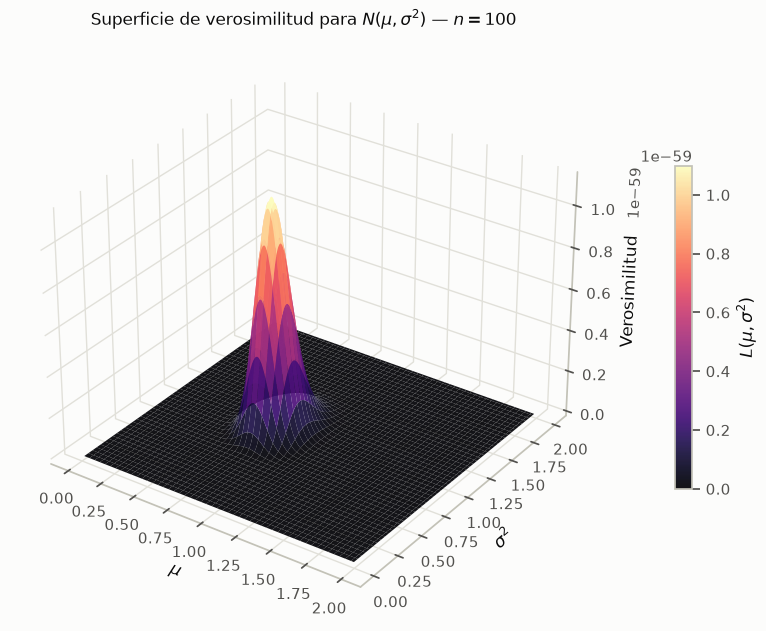

In [18]:
fig = plt.figure(figsize=(10, 6.5))
ax = fig.add_subplot(projection="3d")

# Color de fondo del panel 3D
ax.xaxis.set_pane_color((1, 1, 1, 0.0))
ax.yaxis.set_pane_color((1, 1, 1, 0.0))
ax.zaxis.set_pane_color((1, 1, 1, 0.0))

superficie = ax.plot_surface(MU, SIGMA2, Z, cmap="magma", linewidth=0, antialiased=True, alpha=0.92)
ax.set_xlabel(r"$\mu$")
ax.set_ylabel(r"$\sigma^2$")
ax.set_zlabel("Verosimilitud")
ax.set_title(r"Superficie de verosimilitud para $N(\mu, \sigma^2)$ — $n=100$")
ax.view_init(elev=30, azim=-55)
fig.colorbar(superficie, ax=ax, shrink=0.55, aspect=18, pad=0.08, label=r"$L(\mu, \sigma^2)$")
plt.tight_layout()
plt.show()

La superficie muestra que la verosimilitud tiene un máximo bien definido cerca de $(\mu, \sigma^2) \approx (1, 1)$, que es el verdadero valor poblacional. La masa de probabilidad se concentra cerca de $(\bar{X}, S^2)$.

### 6.2. Optimización numérica con `scipy.optimize.minimize`

In [19]:
def norm_verosimilitud_log(mu_v, sigma2_v, datos):
    """Log-verosimilitud de una N(mu, sigma^2) sobre `datos`."""
    n_d = len(datos)
    return -n_d / 2 * math.log(2 * math.pi * sigma2_v) - np.sum((datos - mu_v) ** 2) / (2 * sigma2_v)

def norm_verosimilitud_log_datos(params, datos):
    """Log-verosimilitud negativa (a minimizar)."""
    mu_v, sigma2_v = params
    return -norm_verosimilitud_log(mu_v, sigma2_v, datos)

punto_inicial = [0.01, 0.01]
resultado = minimize(lambda p: norm_verosimilitud_log_datos(p, muestra_norm), punto_inicial)
mu_optimo, sigma2_optimo = resultado.x
mu_optimo, sigma2_optimo

(0.7904481285103089, 0.8839575208500726)

In [20]:
# Comparacion con las formulas cerradas
mu_cerrado = float(np.mean(muestra_norm))
sigma2_cerrado = float(np.sum((muestra_norm - mu_cerrado) ** 2) / n_norm)

print(f"Punto de partida       : mu={punto_inicial[0]}, sigma2={punto_inicial[1]}")
print(f"max(Z) sobre la malla  : {Z_max:.4e}")
print(f"max L en (Xbar, S^2)   : {norm_verosimilitud_func(mu_cerrado, sigma2_cerrado):.4e}")
print()
print(f"mu_MLE   (formula cerrada)  = {mu_cerrado:.10f}")
print(f"mu_MLE   (scipy.optimize)   = {mu_optimo:.10f}")
print(f"sigma^2_MLE (formula cerrada) = {sigma2_cerrado:.10f}")
print(f"sigma^2_MLE (scipy.optimize)  = {sigma2_optimo:.10f}")

Punto de partida       : mu=0.01, sigma2=0.01
max(Z) sobre la malla  : 1.1337e-59
max L en (Xbar, S^2)   : 1.1343e-59

mu_MLE   (formula cerrada)  = 0.7904481294
mu_MLE   (scipy.optimize)   = 0.7904481285
sigma^2_MLE (formula cerrada) = 0.8839575307
sigma^2_MLE (scipy.optimize)  = 0.8839575209


**Conclusión 5.3.** Los estimadores de máxima verosimilitud para una muestra $N(\mu, \sigma^2)$ son

$$
\hat{\mu}_{\text{MLE}} = \bar{X}, \qquad \hat{\sigma}^2_{\text{MLE}} = \frac{1}{n} \sum_{i=1}^{n} (X_i - \bar{X})^2.
$$

En este experimento con $n=100$ y semilla `20260929`:

- El optimizador numérico recupera $(\hat{\mu}, \hat{\sigma}^2) \approx (0.790, 0.884)$, idéntico al valor que producen las fórmulas cerradas, y muy cercano al máximo de la malla de la superficie de verosimilitud (con la precisión del paso `0.01`).
- Ambos estimadores están cerca de los verdaderos parámetros $(\mu, \sigma^2) = (1, 1)$.
- $\hat{\mu}$ **es insesgado**, mientras que $\hat{\sigma}^2$ **no** es insesgado ($E[\hat{\sigma}^2] = \frac{n-1}{n}\sigma^2$). Para muestras pequeñas o para reportar un estimador insesgado de la varianza se prefiere el divisor $n-1$ (que es lo que devuelven `numpy.var(ddof=1)` o `scipy.stats.tvar`).

[Volver al índice](#indice)

<a id="conclusiones"></a>
## 7. Conclusiones

Los tres ejemplos muestran dos familias de procedimientos para obtener estimadores puntuales: por un lado el **método de momentos** (5.2), que iguala momentos poblacionales con muestrales; por el otro la **máxima verosimilitud** (5.3), que maximiza la verosimilitud observada. Para la normal, ambos coinciden en $\hat{\mu} = \bar{X}$ y $\hat{\sigma}^2 = (1/n)\sum (X_i-\bar{X})^2$.

Puntos a recordar:

1. **Estadística** es cualquier función de la muestra que no depende de parámetros desconocidos (Ejemplo 5.1).
2. **Método de momentos**: $\hat{\mu}_{\text{MoM}} = \bar{X}$, $\hat{\sigma}^2_{\text{MoM}} = (1/n)\sum (X_i - \bar{X})^2$.
3. **Máxima verosimilitud**: los mismos estimadores para la normal, derivados aquí con `sympy` y verificados numéricamente con `scipy.optimize.minimize`. La superficie de verosimilitud tiene un máximo claro en $(\bar{X}, S^2)$.
4. Tanto $\hat{\sigma}^2$ (MoM y MLE) **no son insesgados**; el estimador insesgado usa divisor $n-1$.

[Volver al índice](#indice)